# Term-Structure Models on the US Treasury Curve

**Question:** how well do the classic one-factor short-rate models reproduce the actual US Treasury curve, and what does it take to fit it exactly?

The theory is in the [README](../README.md). This notebook implements it section by section on FRED data.
Functions live in the `termstructure` package; this notebook only calls them and plots.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from termstructure import data, curves

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
BP = 1e4  # decimal -> basis points
DATES = {"Normal (2017-06-30)": "2017-06-30",
         "Steep, near zero (2021-06-30)": "2021-06-30",
         "Inverted (2023-06-30)": "2023-06-30"}

## 1. Bootstrapping zero rates from the par curve

FRED's constant-maturity Treasury (CMT) yields are **par yields** on a semiannual bond-equivalent basis.
Quotes shorter than one coupon period are already zero rates. Beyond that, par yields are interpolated onto the
semiannual coupon grid with a monotone cubic (PCHIP; a natural cubic spline overshoots between 10y, 20y and 30y and invents humps) and each discount factor is solved from the par-bond condition

$$\frac{c_n}{2}\sum_{i<n} P(0,T_i) + \left(1+\frac{c_n}{2}\right)P(0,T_n) = 1,$$

which is exactly the recursive bootstrap described in the README. Zero rates are reported continuously compounded, $P(0,T)=e^{-z(T)T}$.

Three dates with different curve shapes are used throughout.

In [2]:
cmt = data.load_cmt()
print(f"CMT data: {cmt.index.min().date()} to {cmt.index.max().date()}, {len(cmt):,} days")

par = pd.DataFrame({label: data.curve_on(d, cmt) for label, d in DATES.items()})
par.index = [f"{m:g}y" if m >= 1 else f"{round(m * 12)}m" for m in par.index]
(par * 100).round(2).rename_axis("maturity").style.format("{:.2f}%")

CMT data: 1990-01-01 to 2026-09-25, 9,585 days


,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
maturity,,,
1m,0.84%,0.05%,5.24%
3m,1.03%,0.05%,5.43%
6m,1.14%,0.06%,5.47%
1y,1.24%,0.07%,5.40%
2y,1.38%,0.25%,4.87%
3y,1.55%,0.46%,4.49%
5y,1.89%,0.87%,4.13%
7y,2.14%,1.21%,3.97%
10y,2.31%,1.45%,3.81%


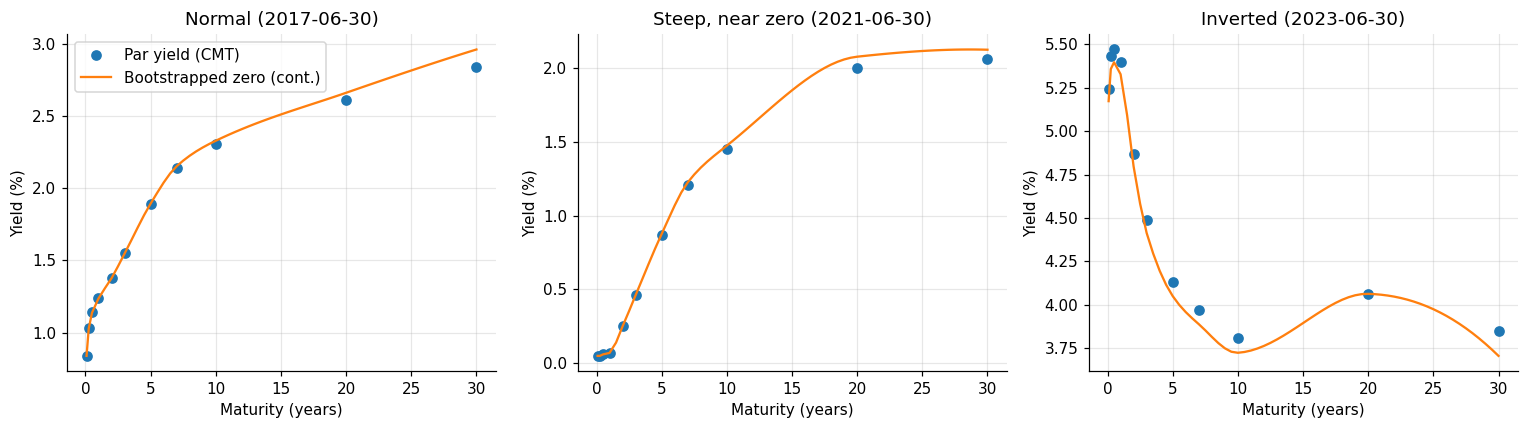

In [3]:
boot = {}
for label, d in DATES.items():
    curve = data.curve_on(d, cmt)
    boot[label] = (curve, *curves.bootstrap_zeros(curve.index.values, curve.values))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (label, (curve, taus, zeros)) in zip(axes, boot.items()):
    ax.plot(curve.index, curve.values * 100, "o", label="Par yield (CMT)")
    ax.plot(taus, zeros * 100, "-", label="Bootstrapped zero (cont.)")
    ax.set(title=label, xlabel="Maturity (years)", ylabel="Yield (%)")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "01_bootstrap.png", bbox_inches="tight")

## 2. Nelson-Siegel fit to the zero curve

$$z(\tau) = \beta_0 + \beta_1\frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_2\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right)$$

$\beta_0$ is the long-run level, $\beta_0+\beta_1$ the instantaneous short rate, and $\beta_2$ the hump.
For fixed $\lambda$ the model is linear in the betas, so the fit grid-searches $\lambda$ with least squares for the betas,
then refines all four jointly. This needs no starting values, unlike the original `nlsLM` fit.

The fit uses the bootstrapped zeros at the **quoted** maturities only, so spline-interpolated points don't get extra weight.
The closed-form instantaneous forward curve $f(0,\tau)$ is what Hull-White needs later.

*Note on 2023:* the 20-year point sits above both the 10- and 30-year. This is a known Treasury anomaly (the 20-year,
reintroduced in 2020, has traded cheap), not a data error, and no smooth three-factor curve can pass through it.
That is why the inverted date has the largest fit error.

In [4]:
ns_fits = {}
for label, (curve, taus, zeros) in boot.items():
    quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
    ns_fits[label] = curves.fit_nelson_siegel(taus[quoted], zeros[quoted])

pd.DataFrame({label: {"beta0 (level, %)": f.b0 * 100, "beta1 (slope, %)": f.b1 * 100,
                      "beta2 (curvature, %)": f.b2 * 100, "lambda": f.lam,
                      "fit RMSE (bp)": f.rmse * BP}
              for label, f in ns_fits.items()}).round(3)

,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
"beta0 (level, %)",3.218,2.489,3.656
"beta1 (slope, %)",-2.288,-2.429,1.328
"beta2 (curvature, %)",0.000,-2.753,3.603
lambda,0.239,0.533,2.130
fit RMSE (bp),5.848,3.296,11.110


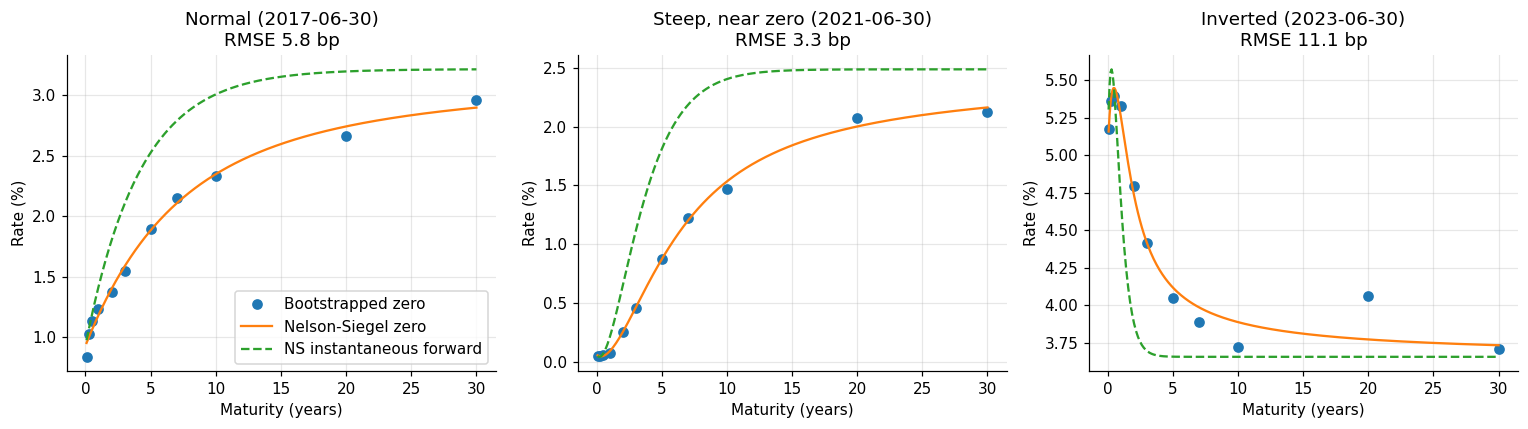

In [5]:
tau_fine = np.linspace(1 / 12, 30, 400)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, (curve, taus, zeros)) in zip(axes, boot.items()):
    fit = ns_fits[label]
    quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
    ax.plot(taus[quoted], zeros[quoted] * 100, "o", label="Bootstrapped zero")
    ax.plot(tau_fine, fit.zero(tau_fine) * 100, "-", label="Nelson-Siegel zero")
    ax.plot(tau_fine, fit.forward(tau_fine) * 100, "--", label="NS instantaneous forward")
    ax.set(title=f"{label}\nRMSE {fit.rmse * BP:.1f} bp", xlabel="Maturity (years)", ylabel="Rate (%)")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "02_nelson_siegel.png", bbox_inches="tight")

## 3. One simulator for the whole one-factor family

The README writes every one-factor model as a special case of

$$dr_t = \left[K_0 + K_1 r_t + K_2\, r_t \log r_t\right]dt + \left[H_0 + H_1 r_t\right]^{v} dB_t^{Q}.$$

`OneFactorModel` implements exactly that equation, so a model is only its coefficients:

| Model | $K_0$ | $K_1$ | $K_2$ | $H_0$ | $H_1$ | $v$ |
|---|---|---|---|---|---|---|
| Vasicek | $\kappa\theta$ | $-\kappa$ | 0 | $\sigma$ | 0 | 1 |
| CIR | $\kappa\theta$ | $-\kappa$ | 0 | 0 | $\sigma^2$ | ½ |
| Dothan | 0 | $\mu$ | 0 | 0 | $\sigma$ | 1 |
| Black-Karasinski | 0 | $\kappa\theta_{\log}+\sigma^2/2$ | $-\kappa$ | 0 | $\sigma$ | 1 |

(Black-Karasinski is $d\log r = \kappa(\theta_{\log}-\log r)dt + \sigma dB$; by Itô that is $K_1=\kappa\theta_{\log}+\sigma^2/2$, $K_2=-\kappa$, $H_1=\sigma$.)

Below are the original toy simulations from the R version (same parameters: $r_0=3\%$, speed 0.1, target 5%, one year of daily steps),
now generated by the one simulator with 20 paths each instead of one. The old "Hull-White" chunk used a constant $\theta$,
which makes it identical to Vasicek, so it is dropped here; a real Hull-White with time-varying $\theta(t)$ comes in section 7.

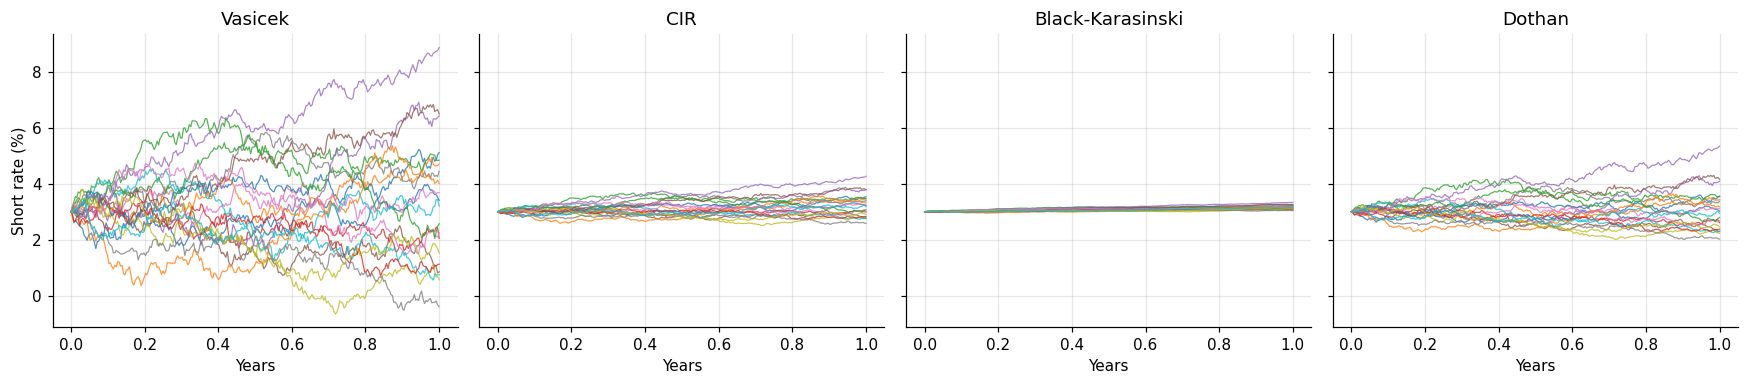

In [6]:
from termstructure.short_rate import OneFactorModel, black_karasinski, dothan, mc_bond_curve
from termstructure.affine import CIR, Vasicek

toy = {  # parameters from the original Term_Structure_Discussions.Rmd
    "Vasicek": (Vasicek(kappa=0.1, theta=0.05, sigma=0.02).general(), "euler"),
    "CIR": (CIR(kappa=0.1, theta=0.05, sigma=0.02).general(), "full_truncation"),
    "Black-Karasinski": (black_karasinski(kappa=0.1, theta_log=np.log(0.05), sigma=0.02), "log_euler"),
    "Dothan": (dothan(mu=0.0, sigma=0.2), "log_euler"),
}
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax, (name, (model, scheme)) in zip(axes, toy.items()):
    t, paths = model.simulate(r0=0.03, T=1.0, dt=1 / 252, n_paths=20, seed=123, scheme=scheme, antithetic=False)
    ax.plot(t, paths * 100, lw=0.8, alpha=0.8)
    ax.set(title=name, xlabel="Years")
axes[0].set_ylabel("Short rate (%)")
fig.tight_layout()
fig.savefig(FIG / "03_one_factor_family.png", bbox_inches="tight")

The same $\sigma = 0.02$ means very different things across models: an absolute volatility of 2 percentage points
per year in Vasicek (paths can go negative), $0.02\sqrt{r}\approx 0.35$ points in CIR, and a 2% *relative* volatility in
Black-Karasinski. This is why the original toy plots looked so different, and why parameters have to be calibrated
per model (section 6) rather than shared.

## 4. Checking $\Lambda_{t,s} = E^Q_t\left[e^{-\int_t^s r_u du}\right]$ numerically

The README defines the bond price as a risk-neutral expectation. For the affine models it also has a closed form,
$P(0,T) = A(T)\,e^{-B(T) r_0}$. If the simulator and the formulas are both right, Monte Carlo estimates of the
expectation must agree with the closed form within sampling error. The simulations use the exact transition laws
(Gaussian for Vasicek, noncentral $\chi^2$ for CIR) on a weekly grid, with the integral done by the trapezoid rule.

In [7]:
r0 = 0.02
maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
models = {"Vasicek": Vasicek(kappa=0.3, theta=0.04, sigma=0.01),
          "CIR": CIR(kappa=0.3, theta=0.04, sigma=0.05)}

rows, mc_yields = [], {}
for name, m in models.items():
    if name == "Vasicek":
        t, paths = m.simulate_exact(r0, 30.0, 1 / 52, 10_000, seed=11)
        prices, se = mc_bond_curve(t, paths, maturities)
    else:
        t, paths = m.simulate_exact(r0, 30.0, 1 / 52, 10_000, seed=11)
        prices, se = mc_bond_curve(t, paths, maturities, antithetic=False)
    exact = m.bond_price(r0, maturities)
    mc_yields[name] = (-np.log(prices) / maturities, se / (prices * maturities))
    for T, p, s, e in zip(maturities, prices, se, exact):
        rows.append({"model": name, "T": T, "closed form": e, "Monte Carlo": p, "std err": s,
                     "|MC - exact| / s.e.": abs(p - e) / s,
                     "yield diff (bp)": (-np.log(p) / T + np.log(e) / T) * BP})
check = pd.DataFrame(rows).set_index(["model", "T"])
check.round({"closed form": 5, "Monte Carlo": 5, "std err": 5, "|MC - exact| / s.e.": 2, "yield diff (bp)": 2})

closed form  Monte Carlo  std err  |MC - exact| / s.e.  \
model   T                                                              
Vasicek 1.0       0.97755      0.97755  0.00000                 1.27   
        2.0       0.95139      0.95139  0.00000                 0.52   
        3.0       0.92294      0.92294  0.00000                 0.51   
        5.0       0.86292      0.86292  0.00001                 0.01   
        7.0       0.80256      0.80254  0.00002                 1.09   
        10.0      0.71627      0.71621  0.00004                 1.54   
        20.0      0.48425      0.48420  0.00008                 0.63   
        30.0      0.32646      0.32651  0.00009                 0.60   
CIR     1.0       0.97754      0.97753  0.00004                 0.21   
        2.0       0.95135      0.95128  0.00010                 0.78   
        3.0       0.92285      0.92272  0.00016                 0.82   
        5.0       0.86270      0.86241  0.00028                 1.03   
        7.0       0.80220      0.80200  0.00037                 0.53   
        10.0      0.71579      0.71560  0.00048                 0.40   
        20.0      0.48374      0.48404  0.00058                 0.51   
        30.0      0.32606      0.32656  0.00051                 0.98   

              yield diff (bp)  
model   T                      
Vasicek 1.0              0.00  
        2.0              0.00  
        3.0             -0.01  
        5.0             -0.00  
        7.0              0.05  
        10.0             0.09  
        20.0             0.05  
        30.0            -0.06  
CIR     1.0              0.08  
        2.0              0.39  
        3.0              0.47  
        5.0              0.66  
        7.0              0.36  
        10.0             0.27  
        20.0            -0.31  
        30.0            -0.51

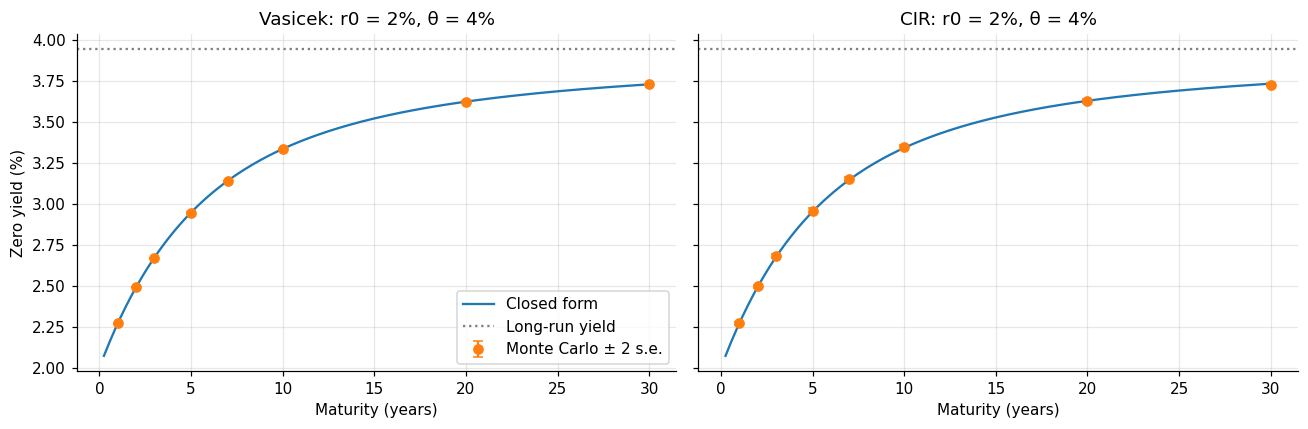

In [8]:
tau = np.linspace(0.25, 30, 200)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    y, y_se = mc_yields[name]
    ax.plot(tau, m.zero_yield(r0, tau) * 100, label="Closed form")
    ax.errorbar(maturities, y * 100, yerr=2 * y_se * 100, fmt="o", capsize=3, label="Monte Carlo ± 2 s.e.")
    ax.axhline(m.long_yield * 100, ls=":", c="gray", label="Long-run yield")
    ax.set(title=f"{name}: r0 = 2%, θ = 4%", xlabel="Maturity (years)")
axes[0].set_ylabel("Zero yield (%)")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "04_mc_vs_closed_form.png", bbox_inches="tight")

### Discretisation matters for CIR

The R version simulated CIR with Euler and then floored the rate at zero, `max(r, 0)`. When the Feller condition
$2\kappa\theta \ge \sigma^2$ fails, paths hit zero often, and flooring pushes them up. That biases bond prices.
Below, a CIR model that violates Feller prices a 10-year bond with three schemes against the closed form.

In [9]:
cir_nf = CIR(kappa=0.3, theta=0.04, sigma=0.2)
print(f"Feller satisfied: {cir_nf.feller}  (2κθ = {2 * cir_nf.kappa * cir_nf.theta:.3f}, σ² = {cir_nf.sigma ** 2:.3f})")
r0_nf, T = 0.01, 10.0
exact_yield = cir_nf.zero_yield(r0_nf, T)

rows = []
for dt_label, dt in [("monthly", 1 / 12), ("weekly", 1 / 52)]:
    for scheme in ["euler_floor", "full_truncation"]:
        t, paths = cir_nf.general().simulate(r0_nf, T, dt, 20_000, seed=5, scheme=scheme)
        p, s = mc_bond_curve(t, paths, [T])
        rows.append({"scheme": scheme, "step": dt_label, "share of steps at 0": (paths[1:] == 0).mean(),
                     "yield error (bp)": (-np.log(p[0]) / T - exact_yield) * BP, "± 2 s.e. (bp)": 2 * s[0] / (p[0] * T) * BP})
    t, paths = cir_nf.simulate_exact(r0_nf, T, dt, 20_000, seed=5)
    p, s = mc_bond_curve(t, paths, [T], antithetic=False)
    rows.append({"scheme": "exact (noncentral χ²)", "step": dt_label, "share of steps at 0": (paths[1:] == 0).mean(),
                 "yield error (bp)": (-np.log(p[0]) / T - exact_yield) * BP, "± 2 s.e. (bp)": 2 * s[0] / (p[0] * T) * BP})
pd.DataFrame(rows).round(3)

Feller satisfied: False  (2κθ = 0.024, σ² = 0.040)


,scheme,step,share of steps at 0,yield error (bp),± 2 s.e. (bp)
0,euler_floor,monthly,0.033,12.730,1.839
1,full_truncation,monthly,0.065,-1.232,1.871
2,exact (noncentral χ²),monthly,0.000,-1.435,2.822
3,euler_floor,weekly,0.014,3.954,1.844
4,full_truncation,weekly,0.027,-1.761,1.847
5,exact (noncentral χ²),weekly,0.000,-2.409,2.819


The floored Euler scheme (the original R approach) overstates the 10-year yield well outside the Monte Carlo noise.
The bias shrinks with a finer grid but does not go away. Full truncation and the exact noncentral-$\chi^2$ transition are both
within sampling error of the closed form. From here on, CIR is simulated with the exact scheme.

## 5. Mean reversion: calibrating to the T-bill history (measure $P$)

A negative $K_1=-\kappa$ is the mean-reversion parameter from the README. Vasicek's exact discretisation is an AR(1),

$$r_{t+\Delta} = a + b\,r_t + \varepsilon_t,\qquad b=e^{-\kappa\Delta},\quad a=\theta(1-b),\quad \operatorname{Var}\varepsilon=\frac{\sigma^2(1-b^2)}{2\kappa},$$

so OLS on weekly data is the exact maximum-likelihood estimator. Standard errors come from the delta method.
CIR is fitted by exact maximum likelihood using its noncentral-$\chi^2$ transition density; zero and negative bill rates
(2009–15, 2020–21) are floored at 1 bp because CIR cannot produce them.

The 3-month T-bill (FRED `DTB3`) is quoted on a bank-discount basis and is converted to a continuous rate first.
Each date uses an **expanding window** from 1990 up to that date, so no information from after the date is used.

In [10]:
from termstructure.calibrate import (fit_cir_mle, fit_to_curve, fit_vasicek_ar1,
                                     tbill_to_continuous, weekly)

raw = data.load_short_rate()
short = weekly(pd.Series(tbill_to_continuous(raw), index=raw.index))

p_fits = {label: (fit_vasicek_ar1(short[:d]), fit_cir_mle(short[:d])) for label, d in DATES.items()}

def pm(value, se, scale=1, digits=3):
    return f"{value * scale:.{digits}f} ± {se * scale:.{digits}f}"

pd.DataFrame({label: {"Vasicek κ": pm(v.model.kappa, v.std_errors["kappa"]),
                      "Vasicek θ (%)": pm(v.model.theta, v.std_errors["theta"], 100, 2),
                      "Vasicek σ (%)": pm(v.model.sigma, v.std_errors["sigma"], 100, 3),
                      "half-life (years)": f"{v.half_life:.1f}",
                      "CIR κ": pm(c.model.kappa, c.std_errors["kappa"]),
                      "CIR θ (%)": pm(c.model.theta, c.std_errors["theta"], 100, 2),
                      "CIR σ": pm(c.model.sigma, c.std_errors["sigma"]),
                      "CIR Feller 2κθ ≥ σ²": c.model.feller,
                      "weekly obs": v.n_obs}
              for label, (v, c) in p_fits.items()})

,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
Vasicek κ,0.116 ± 0.059,0.107 ± 0.055,0.105 ± 0.054
Vasicek θ (%),0.74 ± 1.59,0.36 ± 1.65,1.91 ± 1.22
Vasicek σ (%),0.723 ± 0.014,0.702 ± 0.012,0.708 ± 0.012
half-life (years),6.0,6.5,6.6
CIR κ,0.150 ± 0.068,0.162 ± 0.068,0.102 ± 0.066
CIR θ (%),1.22 ± 0.56,1.13 ± 0.48,1.90 ± 1.20
CIR σ,0.059 ± 0.001,0.060 ± 0.001,0.060 ± 0.001
CIR Feller 2κθ ≥ σ²,True,True,True
weekly obs,1434,1642,1747


The historical long-run mean $	heta_P$ is imprecise (± 1.2–1.7 percentage points) and sits below the sample average rate.
With $b$ this close to 1, $	heta = a/(1-b)$ divides by a tiny number, and a sample in which rates mostly trended down pulls
the estimate low. This is the textbook near-unit-root problem.

Mean reversion is **weakly identified**. Over 27–33 years of data the half-life is about six years, and the standard
error on $\kappa$ is about half its value. Shorter windows are worse, because a decade of rates usually contains one regime
(a zero-rate era, or a hiking cycle) rather than repeated reversions:

In [11]:
rows = {}
for start, end in [("2007-06-30", "2017-06-30"), ("2011-06-30", "2021-06-30"), ("2013-06-30", "2023-06-30")]:
    try:
        v = fit_vasicek_ar1(short[start:end])
        rows[f"{start[:4]}–{end[:4]}"] = {"κ": round(v.model.kappa, 3), "θ (%)": round(v.model.theta * 100, 2),
                                          "half-life (years)": round(v.half_life, 1)}
    except ValueError:
        rows[f"{start[:4]}–{end[:4]}"] = {"κ": "AR(1) b > 1", "θ (%)": "–", "half-life (years)": "no mean reversion"}
pd.DataFrame(rows).T

,κ,θ (%),half-life (years)
2007–2017,1.445,0.18,0.5
2011–2021,0.113,0.63,6.1
2013–2023,AR(1) b > 1,–,no mean reversion


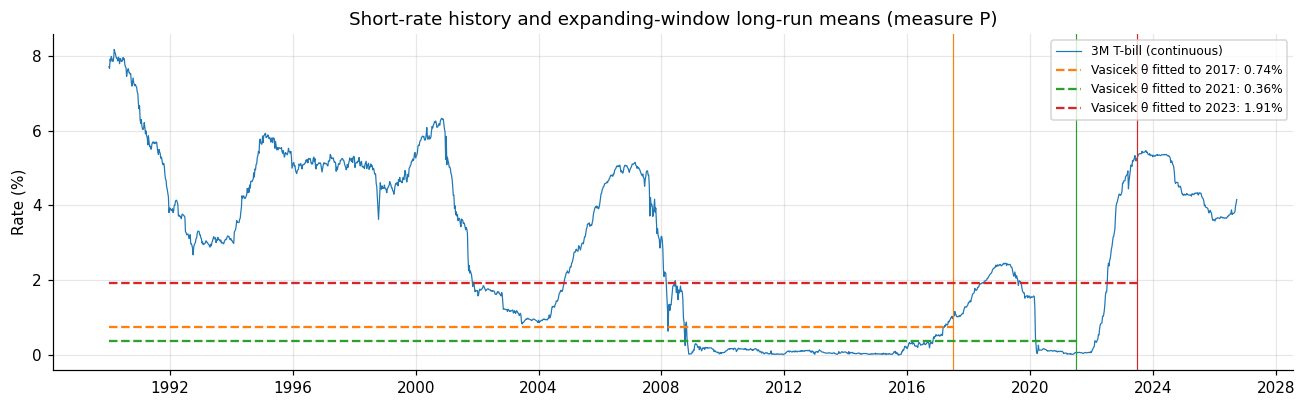

In [12]:
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.plot(short.index, short * 100, lw=0.8, label="3M T-bill (continuous)")
for (label, d), color in zip(DATES.items(), ["C1", "C2", "C3"]):
    v = p_fits[label][0].model
    ax.hlines(v.theta * 100, short.index[0], pd.Timestamp(d), colors=color, linestyles="--",
              label=f"Vasicek θ fitted to {d[:4]}: {v.theta * 100:.2f}%")
    ax.axvline(pd.Timestamp(d), color=color, lw=0.8)
ax.set(ylabel="Rate (%)", title="Short-rate history and expanding-window long-run means (measure P)")
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIG / "05_short_rate_history.png", bbox_inches="tight")

## 6. Do the affine models price the curve?

Two ways to get a model yield curve on each date, both starting from that day's observed short rate $r_0$ (the 1-month zero):

- **Historical ($P$) parameters** from section 5, plugged straight into $y(\tau) = \left(B(\tau)r_0 - \log A(\tau)\right)/\tau$.
- **Curve-implied ($Q$) parameters**: $\kappa$ and $\theta$ chosen so model yields match the bootstrapped zeros.
  $\sigma$ is held at its historical value because, by Girsanov, a change of measure moves only the drift; the diffusion
  coefficient is the same under $P$ and $Q$. (Leaving $\sigma$ free lets the optimiser pick volatilities of 20% or more
  to bend long yields through convexity.)

The difference between the $P$ and $Q$ drifts is the market price of interest-rate risk.

In [13]:
q_fits, errors = {}, {}
for label, (curve, taus, zeros) in boot.items():
    quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
    tq, zq, r0 = taus[quoted], zeros[quoted], zeros[0]
    v_p, c_p = (f.model for f in p_fits[label])
    q_fits[label] = {"Vasicek": fit_to_curve(Vasicek, tq, zq, r0, v_p.sigma),
                     "CIR": fit_to_curve(CIR, tq, zq, r0, c_p.sigma)}
    rmse = lambda y: np.sqrt(np.mean((y - zq) ** 2)) * BP
    errors[label] = {"Vasicek, historical (P)": rmse(v_p.zero_yield(r0, tq)),
                     "CIR, historical (P)": rmse(c_p.zero_yield(max(r0, 1e-4), tq)),
                     "Vasicek, curve-fitted (Q)": q_fits[label]["Vasicek"].rmse_bp,
                     "CIR, curve-fitted (Q)": q_fits[label]["CIR"].rmse_bp}

pd.DataFrame({label: {"θ historical (P), %": p_fits[label][0].model.theta * 100,
                      "θ curve-implied (Q), %": q["Vasicek"].model.theta * 100,
                      "θ_Q − θ_P (pp)": (q["Vasicek"].model.theta - p_fits[label][0].model.theta) * 100,
                      "κ historical (P)": p_fits[label][0].model.kappa,
                      "κ curve-implied (Q)": q["Vasicek"].model.kappa}
              for label, q in q_fits.items()}).round(3)

,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
"θ historical (P), %",0.741,0.365,1.910
"θ curve-implied (Q), %",3.187,3.007,3.574
θ_Q − θ_P (pp),2.446,2.642,1.663
κ historical (P),0.116,0.107,0.105
κ curve-implied (Q),0.277,0.142,0.409


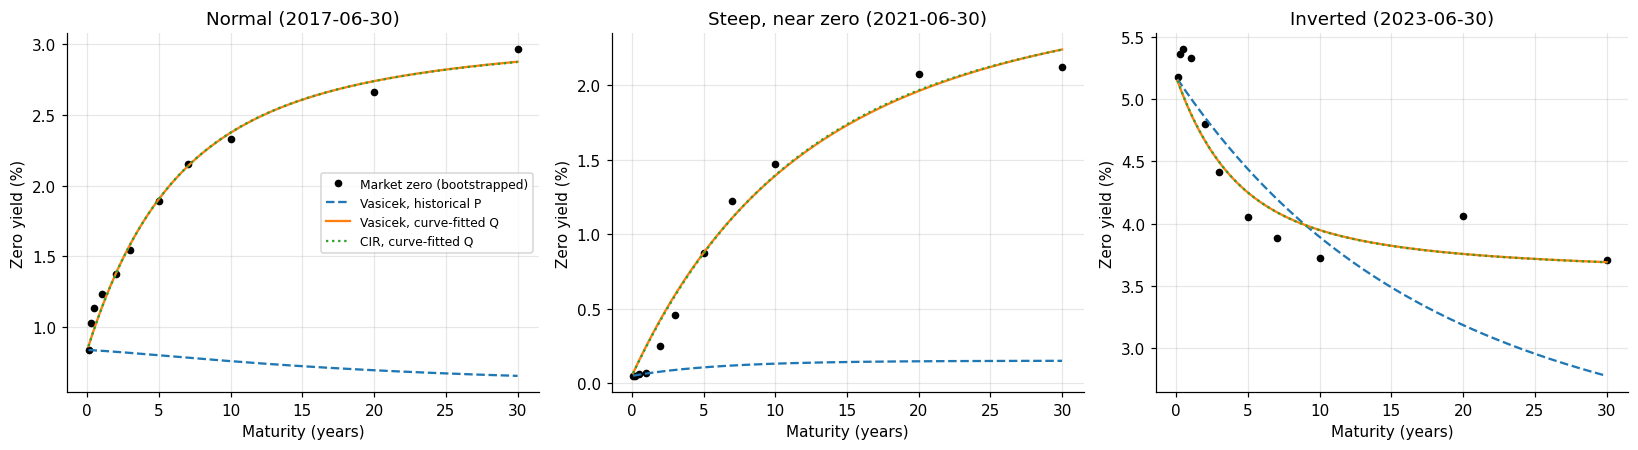

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (label, (curve, taus, zeros)) in zip(axes, boot.items()):
    quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
    r0 = zeros[0]
    v_p = p_fits[label][0].model
    ax.plot(taus[quoted], zeros[quoted] * 100, "ko", ms=4, label="Market zero (bootstrapped)")
    ax.plot(tau_fine, v_p.zero_yield(r0, tau_fine) * 100, "--", label="Vasicek, historical P")
    ax.plot(tau_fine, q_fits[label]["Vasicek"].model.zero_yield(r0, tau_fine) * 100, "-", label="Vasicek, curve-fitted Q")
    ax.plot(tau_fine, q_fits[label]["CIR"].model.zero_yield(max(r0, 1e-4), tau_fine) * 100, ":", label="CIR, curve-fitted Q")
    ax.set(title=label, xlabel="Maturity (years)", ylabel="Zero yield (%)")
axes[0].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "06_model_vs_market.png", bbox_inches="tight")

Historical parameters miss the curve by tens of basis points: their long-run level $\theta_P$ is dragged down by the
zero-rate years, while the curve prices a long-run rate around 3–3.6%. Fitting the drift to the curve closes most of the gap,
but a time-homogeneous one-factor model has only one shape. It is exponential in maturity, so it misses the humped 2021 curve
and the inverted 2023 curve (where the front end rises before falling) by 10–25 bp.

## 7. Hull-White: fitting today's curve exactly

The README's "time-varying coefficients" section is the fix. Let the target depend on time:

$$dr_t = \left(\theta(t) - a\,r_t\right)dt + \sigma\,dB_t^Q,\qquad \theta(t) = \frac{\partial f(0,t)}{\partial t} + a\,f(0,t) + \frac{\sigma^2}{2a}\left(1-e^{-2at}\right).$$

With the Nelson-Siegel forward curve from section 2 as $f(0,t)$ (smooth and differentiable in closed form), model bond prices
equal the fitted curve by construction. The two constants are taken from the historical Vasicek fit ($a=\kappa_P$, $\sigma=\sigma_P$):
the **dynamics come from history, the drift from today's curve**. It is simulated exactly as $r_t = x_t + \alpha(t)$ with $x$ a
zero-mean Ornstein-Uhlenbeck process, and Monte Carlo bond prices are checked against the market curve.

In [15]:
from termstructure.hull_white import HullWhite

hw_models = {label: HullWhite(a=p_fits[label][0].model.kappa, sigma=p_fits[label][0].model.sigma, curve=ns_fits[label])
             for label in DATES}
hw_rows, hw_mc = [], {}
check_T = np.array([1, 2, 3, 5, 7, 10, 20, 30], dtype=float)
for label, hw in hw_models.items():
    t, paths = hw.simulate_exact(30.0, 1 / 52, 10_000, seed=21)
    prices, se = mc_bond_curve(t, paths, check_T)
    target = hw.curve.discount(check_T)
    hw_mc[label] = (-np.log(prices) / check_T, se / (prices * check_T))
    yield_diff = (-np.log(prices) / check_T + np.log(target) / check_T) * BP
    hw_rows.append({"date": label, "a": hw.a, "σ (%)": hw.sigma * 100,
                    "max |yield diff| (bp)": np.max(np.abs(yield_diff)),
                    "2 s.e. at 30y (bp)": 2 * hw_mc[label][1][-1] * BP})
pd.DataFrame(hw_rows).set_index("date").round(3)

,a,σ (%),max |yield diff| (bp),2 s.e. at 30y (bp)
date,,,,
Normal (2017-06-30),0.116,0.723,0.369,0.469
"Steep, near zero (2021-06-30)",0.107,0.702,0.391,0.495
Inverted (2023-06-30),0.105,0.708,0.412,0.520


Monte Carlo reprices every curve to within half a basis point at all maturities, inside the sampling noise.
One subtlety: at 1 year the antithetic standard error is tiny (about 0.003 bp), so the trapezoid rule's deterministic bias on the
weekly grid (about 0.02 bp, largest for the sharply bending 2023 forward curve) shows up as several standard errors there.
Rerunning on a daily grid removes it.

The left panel shows the cost of fitting exactly. $	heta(t)$ contains $\partial f(0,t)/\partial t$, so any sharp bend in the fitted forward
curve is amplified: the 2023 curve's steep front end (Nelson-Siegel $\lambda pprox 2.1$) implies a target that spikes near
$t=0$ and dips below zero around one year. In practice $	heta(t)$ is only as good as the smoothness of the input curve.

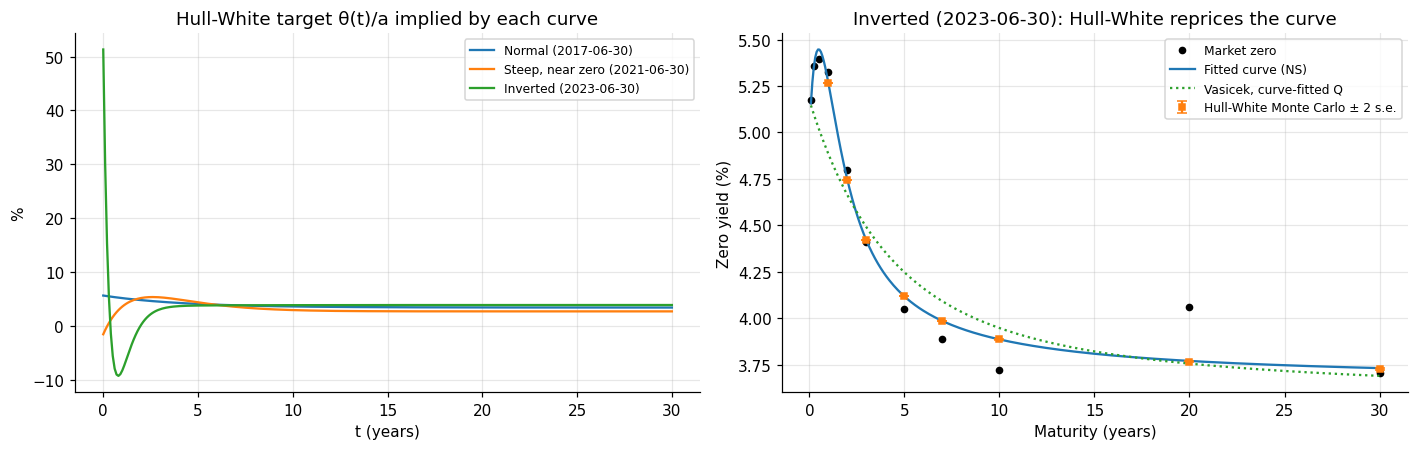

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
t_grid = np.linspace(0, 30, 300)
for label, hw in hw_models.items():
    axes[0].plot(t_grid, hw.theta(t_grid) / hw.a * 100, label=label)
axes[0].set(title="Hull-White target θ(t)/a implied by each curve", xlabel="t (years)", ylabel="%")
axes[0].legend(fontsize=8)

label = "Inverted (2023-06-30)"
curve, taus, zeros = boot[label]
quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
y, y_se = hw_mc[label]
axes[1].plot(taus[quoted], zeros[quoted] * 100, "ko", ms=4, label="Market zero")
axes[1].plot(tau_fine, ns_fits[label].zero(tau_fine) * 100, label="Fitted curve (NS)")
axes[1].errorbar(check_T, y * 100, yerr=2 * y_se * 100, fmt="s", ms=4, capsize=3, label="Hull-White Monte Carlo ± 2 s.e.")
axes[1].plot(tau_fine, q_fits[label]["Vasicek"].model.zero_yield(zeros[0], tau_fine) * 100, ":", label="Vasicek, curve-fitted Q")
axes[1].set(title=f"{label}: Hull-White reprices the curve", xlabel="Maturity (years)", ylabel="Zero yield (%)")
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "07_hull_white.png", bbox_inches="tight")

## Results

Root-mean-square error between model and market zero yields at the quoted maturities, in basis points.
Hull-White reproduces the fitted Nelson-Siegel curve exactly (Monte Carlo agrees within sampling error), so its error
against the market is the Nelson-Siegel fit error. That remaining error is the curve-fitting step, not the dynamics.

In [17]:
results = pd.DataFrame(errors)
results.loc["Hull-White (a, σ historical; θ(t) from curve)"] = [ns_fits[label].rmse * BP for label in DATES]
results.round(1)

,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
"Vasicek, historical (P)",120.1,101.7,45.1
"CIR, historical (P)",100.4,66.3,49.1
"Vasicek, curve-fitted (Q)",7.5,11.2,24.4
"CIR, curve-fitted (Q)",7.5,10.9,24.4
"Hull-White (a, σ historical; θ(t) from curve)",5.8,3.3,11.1
